# Audit détaillé de la qualité des données industrielles MECHA

Ce notebook reprend l'analyse réalisée dans Power BI, mais en Python, pour documenter proprement l'audit des données :

- comparaison **RAW vs CLEAN** ;
- valeurs manquantes ;
- valeurs aberrantes ;
- distributions ;
- indicateurs métier ;
- scoring de maturité data.




## 1. Import des librairies et configuration

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

# Chemins du projet
ROOT_DIR = Path.cwd()
RAW_DIR = ROOT_DIR / 'data' / 'raw'
CLEAN_DIR = ROOT_DIR / 'data' / 'clean'

print('Dossier courant :', ROOT_DIR)
print('Dossier RAW :', RAW_DIR)
print('Dossier CLEAN :', CLEAN_DIR)


Dossier courant : d:\ecole\MSPR_TPRE831
Dossier RAW : d:\ecole\MSPR_TPRE831\data\raw
Dossier CLEAN : d:\ecole\MSPR_TPRE831\data\clean


## 2. Chargement des fichiers RAW et CLEAN

On charge automatiquement tous les fichiers CSV présents dans `data/raw` et `data/clean`.


In [3]:
def load_csv_folder(folder: Path) -> dict:
    data = {}
    if not folder.exists():
        raise FileNotFoundError(f'Dossier introuvable : {folder}')
    
    for file in sorted(folder.glob('*.csv')):
        name = file.stem
        data[name] = pd.read_csv(file)
        print(f'{name:<25} -> {data[name].shape[0]} lignes, {data[name].shape[1]} colonnes')
    return data

raw = load_csv_folder(RAW_DIR)
clean = load_csv_folder(CLEAN_DIR)


energie_sale              -> 300 lignes, 7 colonnes
erp_sale                  -> 300 lignes, 14 colonnes
gmao_sale                 -> 300 lignes, 15 colonnes
mes_sale                  -> 300 lignes, 28 colonnes
scada_capteurs_sale       -> 300 lignes, 19 colonnes
energie_propre            -> 300 lignes, 7 colonnes
erp_propre                -> 300 lignes, 14 colonnes
gmao_propre               -> 300 lignes, 15 colonnes
mes_propre                -> 300 lignes, 28 colonnes
scada_capteurs_propre     -> 300 lignes, 19 colonnes


## 3. Normalisation légère des données

Cette étape ne remplace pas le nettoyage métier déjà fait dans le pipeline. Elle sert uniquement à fiabiliser l'audit :

- transformer les faux vides (`""`, `"nan"`, `"NULL"`) en `NaN` ;
- convertir les colonnes numériques connues ;
- convertir les dates quand elles existent.


In [4]:
NUMERIC_COLUMNS = {
    'planned_production_qty', 'actual_production_qty', 'good_qty', 'scrap_qty',
    'cycle_time_sec', 'target_cycle_time_sec', 'production_speed',
    'downtime_minutes', 'setup_time_minutes', 'quality_score',
    'energy_consumption_kwh', 'compressed_air_usage', 'cooling_water_usage', 'power_peak_kw',
    'Temperature_C', 'Vibration_mms', 'Sound_dB', 'Oil_Level_pct', 'Coolant_Level_pct',
    'Hydraulic_Pressure_bar', 'Coolant_Flow_L_min', 'Heat_Index', 'Power_Consumption_kW',
    'Last_Maintenance_Days_Ago', 'Maintenance_History_Count', 'Failure_History_Count',
    'repair_time_minutes', 'maintenance_cost', 'energy_cost', 'Installation_Year'
}

MISSING_MARKERS = ['', ' ', 'None', 'none', 'NULL', 'null', 'nan', 'NaN']

def normalize_for_audit(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df.replace(MISSING_MARKERS, np.nan)
    
    for col in df.columns:
        if col == 'timestamp':
            df[col] = pd.to_datetime(df[col], errors='coerce')
        elif col in NUMERIC_COLUMNS:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

raw = {name: normalize_for_audit(df) for name, df in raw.items()}
clean = {name: normalize_for_audit(df) for name, df in clean.items()}

print('Normalisation terminée.')


Normalisation terminée.


## 4. Synthèse globale de l'audit : RAW vs CLEAN

Cette partie correspond à la page 1 du rapport interactif : elle donne une vision globale de l'état des données avant et après nettoyage.


In [5]:
SOURCE_MAPPING = {
    'Énergie': ('energie_sale', 'energie_propre'),
    'MES': ('mes_sale', 'mes_propre'),
    'SCADA': ('scada_capteurs_sale', 'scada_capteurs_propre'),
    'GMAO': ('gmao_sale', 'gmao_propre'),
    'ERP': ('erp_sale', 'erp_propre'),
}

def total_missing(df: pd.DataFrame) -> int:
    return int(df.isna().sum().sum())

def total_cells(df: pd.DataFrame) -> int:
    return int(df.shape[0] * df.shape[1])

summary_rows = []
for source, (raw_name, clean_name) in SOURCE_MAPPING.items():
    raw_df = raw.get(raw_name)
    clean_df = clean.get(clean_name)
    if raw_df is None or clean_df is None:
        continue
    summary_rows.append({
        'source': source,
        'raw_rows': len(raw_df),
        'clean_rows': len(clean_df),
        'raw_missing': total_missing(raw_df),
        'clean_missing': total_missing(clean_df),
        'raw_cells': total_cells(raw_df),
        'clean_cells': total_cells(clean_df),
        'raw_missing_pct': total_missing(raw_df) / total_cells(raw_df),
        'clean_missing_pct': total_missing(clean_df) / total_cells(clean_df),
    })

summary = pd.DataFrame(summary_rows)
summary


,source,raw_rows,clean_rows,raw_missing,clean_missing,raw_cells,clean_cells,raw_missing_pct,clean_missing_pct
0,Énergie,300,300,100,0,2100,2100,0.047619,0.000000
1,MES,300,300,678,290,8400,8400,0.080714,0.034524
2,SCADA,300,300,275,0,5700,5700,0.048246,0.000000
3,GMAO,300,300,281,0,4500,4500,0.062444,0.000000
4,ERP,300,300,202,0,4200,4200,0.048095,0.000000


In [6]:
total_missing_raw = summary['raw_missing'].sum()
total_missing_clean = summary['clean_missing'].sum()
total_cells_raw = summary['raw_cells'].sum()
total_cells_clean = summary['clean_cells'].sum()

kpi_global = pd.DataFrame({
    'Indicateur': [
        'Valeurs manquantes RAW',
        'Valeurs manquantes CLEAN',
        '% valeurs manquantes RAW',
        '% valeurs manquantes CLEAN',
        'Taux amélioration complétude'
    ],
    'Valeur': [
        total_missing_raw,
        total_missing_clean,
        total_missing_raw / total_cells_raw,
        total_missing_clean / total_cells_clean,
        (total_missing_raw - total_missing_clean) / total_missing_raw if total_missing_raw else 0
    ]
})

kpi_global


,Indicateur,Valeur
0,Valeurs manquantes RAW,1536.000000
1,Valeurs manquantes CLEAN,290.000000
2,% valeurs manquantes RAW,0.061687
3,% valeurs manquantes CLEAN,0.011647
4,Taux amélioration complétude,0.811198


### Visualisation : valeurs manquantes par source

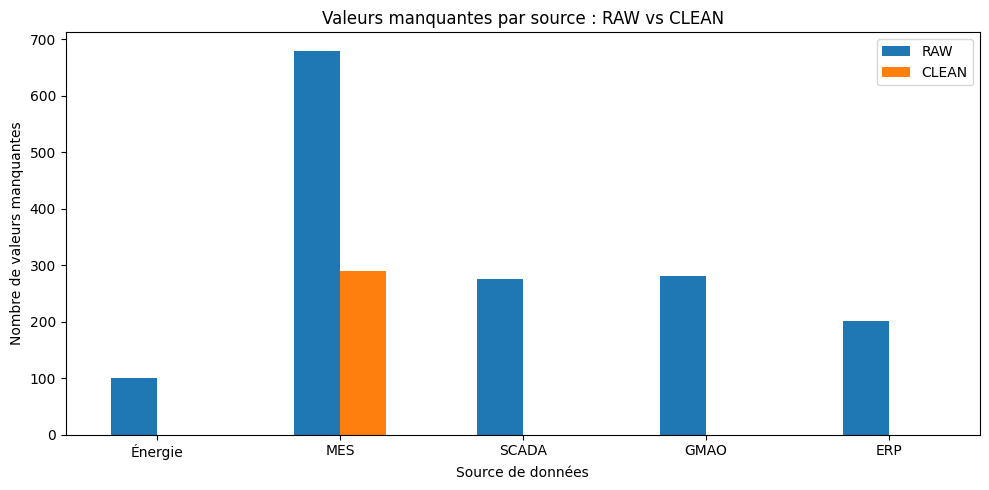

In [7]:
ax = summary.set_index('source')[['raw_missing', 'clean_missing']].plot(kind='bar', figsize=(10, 5))
ax.set_title('Valeurs manquantes par source : RAW vs CLEAN')
ax.set_xlabel('Source de données')
ax.set_ylabel('Nombre de valeurs manquantes')
ax.legend(['RAW', 'CLEAN'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Définition des règles d'anomalies métier

Les règles ci-dessous sont alignées avec la logique de nettoyage du script `etl_data.py` :

- énergie : `energy_consumption_kwh < 0` ou `> 150` ;
- cycle SCADA : `cycle_time_sec < 20` ou `> 120` ;
- scrap : `scrap_qty < 0` ou `> 500` ;
- downtime : `downtime_minutes < 0` ou `> 500` ;
- quantité planifiée : `planned_production_qty <= 0` ou `> 3000`.


In [8]:
ANOMALY_RULES = {
    'Énergie hors seuil': ('energie_sale', 'energie_propre', 'energy_consumption_kwh', lambda s: (s < 0) | (s > 150)),
    'Cycle hors seuil': ('scada_capteurs_sale', 'scada_capteurs_propre', 'cycle_time_sec', lambda s: (s < 20) | (s > 120)),
    'Scrap incohérent': ('mes_sale', 'mes_propre', 'scrap_qty', lambda s: (s < 0) | (s > 500)),
    'Downtime incohérent': ('gmao_sale', 'gmao_propre', 'downtime_minutes', lambda s: (s < 0) | (s > 500)),
    'Production planifiée incohérente': ('erp_sale', 'erp_propre', 'planned_production_qty', lambda s: (s <= 0) | (s > 3000)),
}

def count_anomalies(df: pd.DataFrame, col: str, rule) -> int:
    if df is None or col not in df.columns:
        return 0
    s = pd.to_numeric(df[col], errors='coerce')
    return int(rule(s).fillna(False).sum())

anomaly_rows = []
for anomaly_type, (raw_name, clean_name, col, rule) in ANOMALY_RULES.items():
    anomaly_rows.append({
        'type_anomalie': anomaly_type,
        'colonne': col,
        'raw_anomalies': count_anomalies(raw.get(raw_name), col, rule),
        'clean_anomalies': count_anomalies(clean.get(clean_name), col, rule),
    })

anomalies = pd.DataFrame(anomaly_rows)
anomalies


,type_anomalie,colonne,raw_anomalies,clean_anomalies
0,Énergie hors seuil,energy_consumption_kwh,6,0
1,Cycle hors seuil,cycle_time_sec,6,0
2,Scrap incohérent,scrap_qty,9,0
3,Downtime incohérent,downtime_minutes,6,0
4,Production planifiée incohérente,planned_production_qty,6,0


### Visualisation : anomalies par type

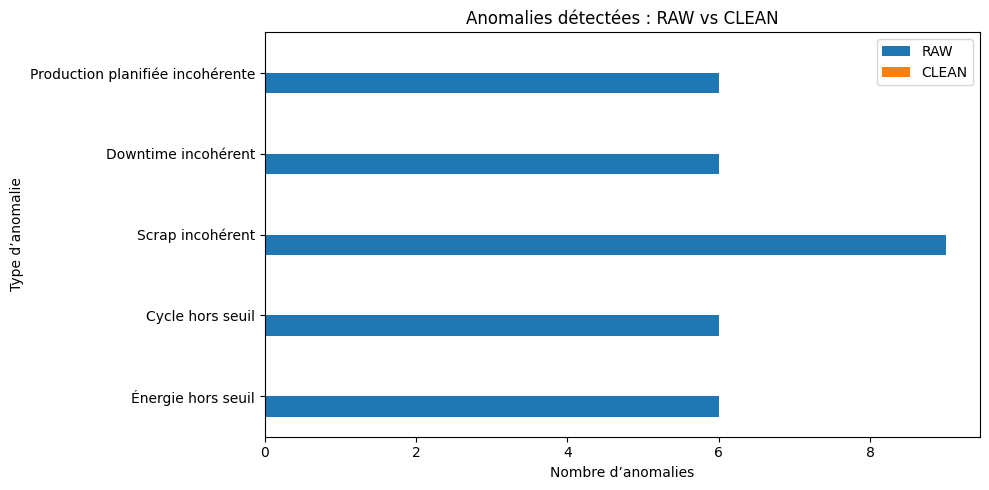

In [9]:
ax = anomalies.set_index('type_anomalie')[['raw_anomalies', 'clean_anomalies']].plot(kind='barh', figsize=(10, 5))
ax.set_title('Anomalies détectées : RAW vs CLEAN')
ax.set_xlabel('Nombre d’anomalies')
ax.set_ylabel('Type d’anomalie')
ax.legend(['RAW', 'CLEAN'])
plt.tight_layout()
plt.show()


## 6. Valeurs manquantes par colonne

Cette section correspond au détail de la page 2 Power BI : elle permet d'identifier quelles colonnes sont les plus touchées.


In [10]:
def missing_by_column(data: dict, dataset_name: str) -> pd.DataFrame:
    df = data[dataset_name]
    out = df.isna().sum().reset_index()
    out.columns = ['colonne', 'missing_count']
    out['missing_pct'] = out['missing_count'] / len(df)
    out['dataset'] = dataset_name
    return out.sort_values('missing_count', ascending=False)

missing_detail_raw = pd.concat([
    missing_by_column(raw, name) for name in raw.keys()
], ignore_index=True)

missing_detail_clean = pd.concat([
    missing_by_column(clean, name) for name in clean.keys()
], ignore_index=True)

missing_detail_raw.head(20)


,colonne,missing_count,missing_pct,dataset
0,timestamp,20,0.066667,energie_sale
1,compressed_air_usage,20,0.066667,energie_sale
2,energy_consumption_kwh,19,0.063333,energie_sale
3,machine_id,15,0.050000,energie_sale
4,power_peak_kw,9,0.030000,energie_sale
5,energy_cost,9,0.030000,energie_sale
6,cooling_water_usage,8,0.026667,energie_sale
7,technician_id,22,0.073333,erp_sale
8,shift,21,0.070000,erp_sale
9,failure_severity,18,0.060000,erp_sale


In [ ]:
top_missing = missing_detail_raw[missing_detail_raw['missing_count'] > 0].head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_missing['dataset'] + ' / ' + top_missing['colonne'], top_missing['missing_count'])
plt.title('Top 20 des valeurs manquantes par colonne dans les données RAW')
plt.xlabel('Nombre de valeurs manquantes')
plt.ylabel('Dataset / colonne')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 7. Distribution des données énergétiques

L'histogramme permet de visualiser le comportement normal et les valeurs extrêmes. Ici, on compare la distribution de `energy_consumption_kwh` avant et après nettoyage.


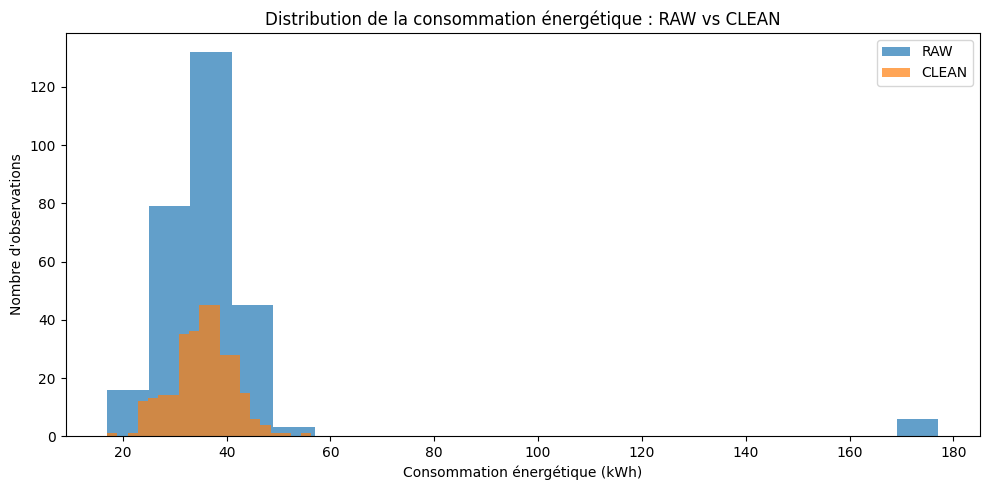

In [11]:
energy_raw = raw['energie_sale']['energy_consumption_kwh'].dropna()
energy_clean = clean['energie_propre']['energy_consumption_kwh'].dropna()

plt.figure(figsize=(10, 5))
plt.hist(energy_raw, bins=20, alpha=0.7, label='RAW')
plt.hist(energy_clean, bins=20, alpha=0.7, label='CLEAN')
plt.title('Distribution de la consommation énergétique : RAW vs CLEAN')
plt.xlabel('Consommation énergétique (kWh)')
plt.ylabel("Nombre d'observations")
plt.legend()
plt.tight_layout()
plt.show()


### Interprétation

- La majorité des valeurs se concentre autour d'une plage normale.
- Les valeurs très éloignées de cette plage peuvent être interprétées comme des anomalies ou des erreurs de capteur.
- Après nettoyage, la distribution est normalement plus homogène et plus exploitable pour la BI et l'IA.


## 8. Analyse des capteurs SCADA : cycle time

Le temps de cycle est un indicateur critique dans le pilotage industriel. Un cycle trop court ou trop long peut signaler une erreur de mesure ou une dérive process.


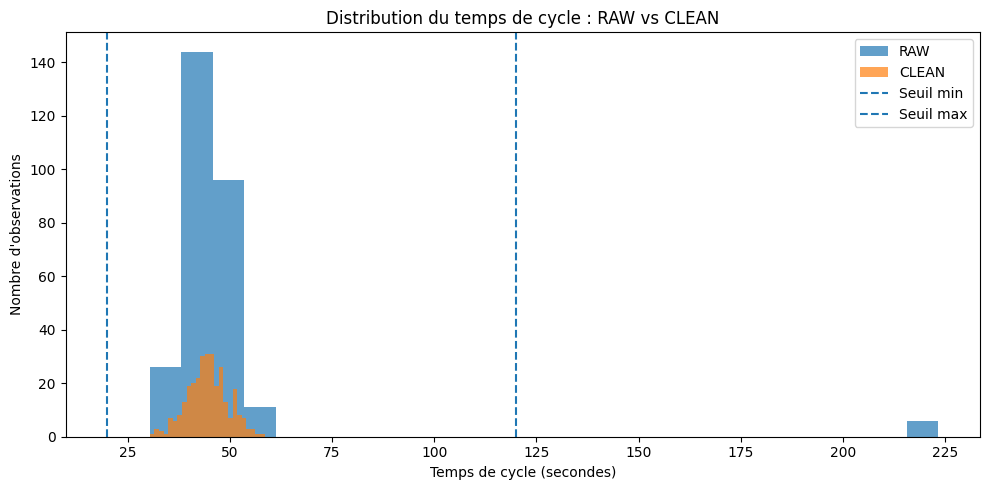

In [12]:
cycle_raw = raw['scada_capteurs_sale']['cycle_time_sec'].dropna()
cycle_clean = clean['scada_capteurs_propre']['cycle_time_sec'].dropna()

plt.figure(figsize=(10, 5))
plt.hist(cycle_raw, bins=25, alpha=0.7, label='RAW')
plt.hist(cycle_clean, bins=25, alpha=0.7, label='CLEAN')
plt.axvline(20, linestyle='--', label='Seuil min')
plt.axvline(120, linestyle='--', label='Seuil max')
plt.title('Distribution du temps de cycle : RAW vs CLEAN')
plt.xlabel('Temps de cycle (secondes)')
plt.ylabel("Nombre d'observations")
plt.legend()
plt.tight_layout()
plt.show()


## 9. Analyse métier : production, rebut et qualité

Cette partie prépare la page 3 du rapport interactif : elle montre l'intérêt métier des données nettoyées.


In [13]:
mes_clean = clean['mes_propre'].copy()

for col in ['actual_production_qty', 'good_qty', 'scrap_qty', 'quality_score']:
    mes_clean[col] = pd.to_numeric(mes_clean[col], errors='coerce')

metier_kpis = pd.DataFrame({
    'Indicateur': [
        'Production réelle totale',
        'Quantité conforme totale',
        'Rebuts totaux',
        'Taux de rebut',
        'Score qualité moyen'
    ],
    'Valeur': [
        mes_clean['actual_production_qty'].sum(),
        mes_clean['good_qty'].sum(),
        mes_clean['scrap_qty'].sum(),
        mes_clean['scrap_qty'].sum() / mes_clean['actual_production_qty'].sum(),
        mes_clean['quality_score'].mean()
    ]
})

metier_kpis


,Indicateur,Valeur
0,Production réelle totale,301254.000000
1,Quantité conforme totale,292433.250000
2,Rebuts totaux,8115.316901
3,Taux de rebut,0.026938
4,Score qualité moyen,102.938741


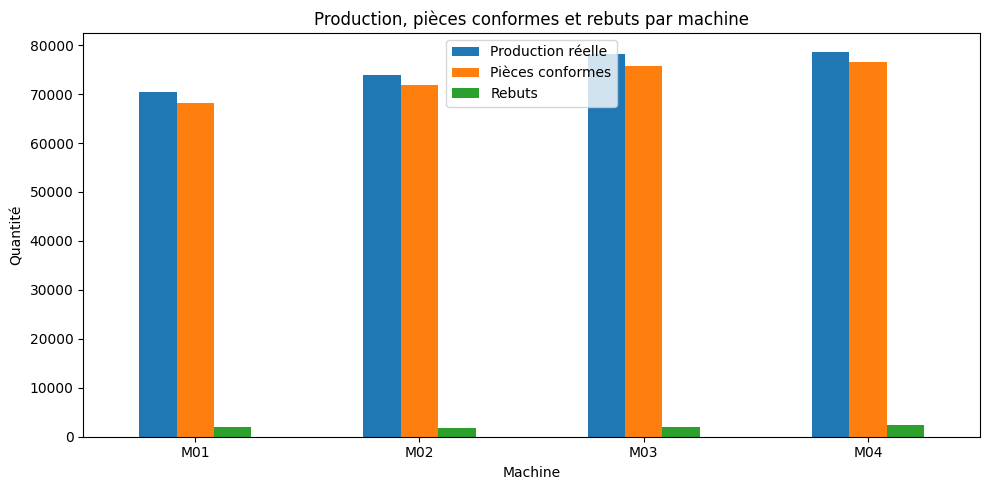

In [14]:
prod_by_machine = mes_clean.groupby('machine_id', dropna=False)[['actual_production_qty', 'good_qty', 'scrap_qty']].sum().sort_index()

ax = prod_by_machine[['actual_production_qty', 'good_qty', 'scrap_qty']].plot(kind='bar', figsize=(10, 5))
ax.set_title('Production, pièces conformes et rebuts par machine')
ax.set_xlabel('Machine')
ax.set_ylabel('Quantité')
ax.legend(['Production réelle', 'Pièces conformes', 'Rebuts'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 10. Diagnostic de maturité data

Ce scoring est une proposition synthétique pour la page 4. Il est basé sur les résultats observés : complétude, cohérence, traçabilité, fiabilité et exploitabilité IA.


In [ ]:
# Scores simples et ajustables selon ton argumentaire
raw_missing_rate = total_missing_raw / total_cells_raw
clean_missing_rate = total_missing_clean / total_cells_clean
raw_anomalies = anomalies['raw_anomalies'].sum()
clean_anomalies = anomalies['clean_anomalies'].sum()

completude = max(0, min(10, round((1 - clean_missing_rate) * 10, 1)))
coherence = 10 if clean_anomalies == 0 else max(0, round(10 - clean_anomalies / max(raw_anomalies, 1) * 10, 1))
tracabilite = 8.0  # identifiants industriels présents : machine_id, product_id, work_order_id, batch_id selon sources
fiabilite = round((completude + coherence) / 2, 1)
exploitabilite_ia = round((completude + coherence + tracabilite + fiabilite) / 4 - 1, 1)
exploitabilite_ia = max(0, min(10, exploitabilite_ia))

maturity = pd.DataFrame({
    'Critère': ['Complétude', 'Cohérence', 'Traçabilité', 'Fiabilité', 'Exploitabilité IA'],
    'Score': [completude, coherence, tracabilite, fiabilite, exploitabilite_ia]
})

maturity


In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(maturity['Critère'], maturity['Score'])
plt.ylim(0, 10)
plt.title('Diagnostic de maturité data')
plt.ylabel('Score / 10')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 11. Conclusion de l'audit

Synthèse à reprendre dans le rapport ou à l'oral :

> Les données brutes présentent des valeurs manquantes et des anomalies typiques d'un environnement industriel : trous de mesure, valeurs extrêmes de capteurs, incohérences de production et valeurs non exploitables. Le nettoyage métier permet de réduire ces défauts et d'obtenir des données plus fiables pour la Business Intelligence et les futurs cas d'usage IA.
